<a href="https://colab.research.google.com/github/ghrkarbasi/efficiency-prediction/blob/main/four_ML_DEA_algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pathlib

In [ ]:
import os
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [ ]:
ls

 1-s2.0-S2096232020300469-main.pdf
'applied math nikukar.pdf'
 bcc_results.xlsx
 calculus/
'Colab Notebooks'/
 dataset/
 dataset2/
'data with bcc score.xlsx'
'Data work'/
'deep learninig'/
'Discrete mathematics'/
 generate_data.xlsx
'ja-had elmi.pdf'
 love/
 Machine-Learning-Tom-Mitchell_MatlabKar.com.pdf
 MachinLearning/
 mathematics-11-04873.pdf
'my CV kholaseh.pdf'
'My musice'/
'numpy quiz.png'
'ons ba quran'/
 OR/
'PDF Reader.pdf'
 projects/
'python quiz.png'
 segah.mp3
 TrustWalletBackup/
 Voic/


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# خواندن فایل اکسل
df = pd.read_excel('data with bcc score.xlsx')

# جدا کردن ویژگی‌ها (ستون‌های ۱ تا ۴) و هدف (ستون ۵)
X = df.iloc[:, :4].values   # owners equity, total operational expences, net profit, operational income
y = df.iloc[:, 4].values    # bcc score

# تقسیم به آموزش و تست (80% آموزش، 20% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# استانداردسازی (برای همه الگوریتم‌ها ضروری است)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ایجاد و آموزش شبکه عصبی
bpnn_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # دو لایه پنهان
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
bpnn_model.fit(X_train_scaled, y_train)

# پیش‌بینی روی تست
y_pred_bpnn = bpnn_model.predict(X_test_scaled)

# ارزیابی
mse_bpnn = mean_squared_error(y_test, y_pred_bpnn)
r2_bpnn = r2_score(y_test, y_pred_bpnn)
print(f"BPNN-DEA -> MSE: {mse_bpnn:.5f}, R²: {r2_bpnn:.5f}")

BPNN-DEA -> MSE: 0.00509, R²: 0.77618


In [ ]:
pip install pygad

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.3/218.3 kB 5.5 MB/s eta 0:00:00


In [ ]:
X_train_scaled.shape

(741, 4)

In [ ]:
X_test_scaled.shape

(186, 4)

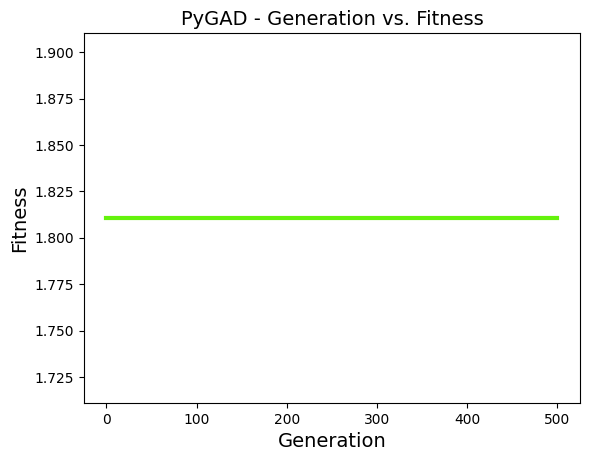

GANN-DEA -> MSE: 0.53581, R²: -22.55832


In [ ]:
import pygad
import pygad.nn
import pygad.gann

# --- تعریف تابع fitness (بر اساس MSE) ---
def fitness_func(ga_instance, solution, sol_idx):
    global GANN_instance, X_train_scaled, y_train
    predictions = pygad.nn.predict(
        last_layer=GANN_instance.population_networks[sol_idx],
        data_inputs=X_train_scaled,
        problem_type="regression"
    )
    mse = np.mean((predictions - y_train) ** 2)
    # هرچه mse کمتر، fitness بیشتر
    return 1.0 / (mse + 1e-10)

# --- تنظیمات GANN ---
num_inputs = X_train_scaled.shape[1]
num_outputs = 1
num_solutions = 8   # تعداد شبکه‌ها در جمعیت (برای سرعت کمتر)

GANN_instance = pygad.gann.GANN(num_neurons_input=num_inputs,
                                num_neurons_output=num_outputs,
                                num_neurons_hidden_layers=[32, 16],
                                output_activation="relu",
                                hidden_activations=["relu", "relu"],
                                num_solutions=num_solutions
                                )
#(num_neurons_input, num_neurons_output, num_neurons_hidden_layers, output_activation, hidden_activations, num_solutions)
population_vectors = pygad.gann.population_as_vectors(
    population_networks=GANN_instance.population_networks
)

ga_instance = pygad.GA(
    num_generations=500,          # تعداد نسل‌ها (برای تست سریع)
    num_parents_mating=10,
    fitness_func=fitness_func,
    initial_population=population_vectors.copy(),
    mutation_percent_genes=5,
    crossover_type="single_point",
    random_seed=42
)

# اجرای الگوریتم ژنتیک
ga_instance.run()

# استخراج بهترین شبکه
best_solution, best_fitness, best_idx = ga_instance.best_solution()
best_network = GANN_instance.population_networks[best_idx]

# پیش‌بینی روی تست
y_pred_gann = pygad.nn.predict(
    last_layer=best_network,
    data_inputs=X_test_scaled,
    problem_type="regression"
)

mse_gann = mean_squared_error(y_test, y_pred_gann)
r2_gann = r2_score(y_test, y_pred_gann)
print(f"GANN-DEA -> MSE: {mse_gann:.5f}, R²: {r2_gann:.5f}")

In [ ]:
from sklearn.svm import SVR

# ایجاد و آموزش SVR با هسته RBF
svm_model = SVR(
    kernel='rbf',
    C=1.0,
    epsilon=0.1,
    gamma='scale'
)
svm_model.fit(X_train_scaled, y_train)

# پیش‌بینی
y_pred_svm = svm_model.predict(X_test_scaled)

mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)
print(f"SVM-DEA -> MSE: {mse_svm:.5f}, R²: {r2_svm:.5f}")

SVM-DEA -> MSE: 0.01075, R²: 0.52745


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

# تعریف فضای جستجو
param_grid = {
    'kernel': ['rbf','linear','poly'],
    'C': [100],
    'epsilon': [0.01, 0.1],
    'gamma': ['auto']
}

# ایجاد مدل پایه و انجام جستجو
base_svr = SVR()
grid_search = GridSearchCV(
    estimator=base_svr,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,                 # برای سرعت، تعداد folds کمتر
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

# بهترین مدل
best_svr = grid_search.best_estimator_
print("بهترین پارامترهای ISVM:", grid_search.best_params_)

y_pred_isvm = best_svr.predict(X_test_scaled)

mse_isvm = mean_squared_error(y_test, y_pred_isvm)
r2_isvm = r2_score(y_test, y_pred_isvm)
print(f"ISVM-DEA -> MSE: {mse_isvm:.5f}, R²: {r2_isvm:.5f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
بهترین پارامترهای ISVM: {'C': 100, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
ISVM-DEA -> MSE: 0.01390, R²: 0.38886


In [ ]:
results = pd.DataFrame({
    'Algorithm': ['BPNN-DEA', 'GANN-DEA', 'SVM-DEA', 'ISVM-DEA'],
    'MSE': [mse_bpnn, mse_gann, mse_svm, mse_isvm],
    'R²': [r2_bpnn, r2_gann, r2_svm, r2_isvm]
})
print(results)

  Algorithm       MSE         R²
0  BPNN-DEA  0.005091   0.776175
1  GANN-DEA  0.534896 -22.517939
2   SVM-DEA  0.010748   0.527446
3  ISVM-DEA  0.013900   0.388864
